In [18]:
import csv
import json

with open("secciones.json") as f:
  datos = json.load(f)
with open("reacciones.json") as f:
  materiales = json.load(f)

energias = []
sigmas = []
with open("cf252_elastic.csv") as g:
  reader = csv.DictReader(g)
  for row in reader:
    energias.append(float(row["energy_eV"]))
    sigmas.append(float(row["sigma_elastic"]))

grupos_energia = [
    (1e6, 2e7),
    (1e5, 1e6),
    (1e4, 1e5),
    (1e3, 1e4),
    (1e2, 1e3),
    (1e1, 1e2),
    (0, 1e1)
]

sigma_grupos = []

for emin, emax in grupos_energia:
  valores = []
  for e, sigma in zip(energias, sigmas):
      if emin <= e <= emax:
          valores.append(sigma)
  if valores:
     promedio = sum(valores) / len(valores)
  else:
    promedio = sigmas[-1] if sigma_grupos else 0

  sigma_grupos.append(promedio)
print("Sigmas por grupo:")
for i, val in enumerate(sigma_grupos):
  print(f"Grupo {i+1}: {val}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Secciones /content/drive/MyDrive/Reactor nuclear proyecto/secciones.json
Reacciones /content/drive/MyDrive/Reactor nuclear proyecto/reacciones.json
CSV /content/drive/MyDrive/Reactor nuclear proyecto/cf252_elastic.csv


Paso 0: N=970, k=0.97, T=325.6, Estado=Subcritico | Vivos=706, Absorbidos=139, Escapados=17)


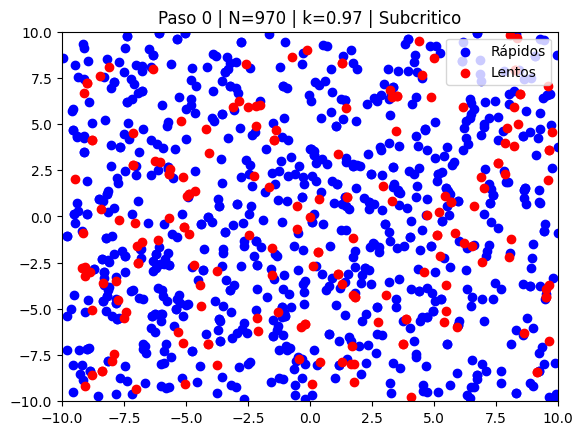

Paso 1: N=909, k=0.94, T=350.0, Estado=Subcritico | Vivos=654, Absorbidos=163, Escapados=21)


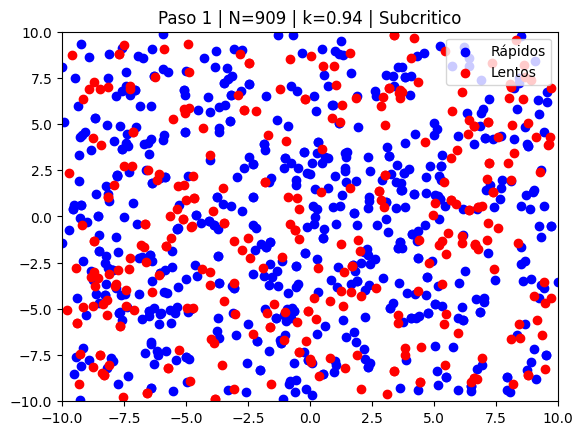

Paso 2: N=874, k=0.96, T=373.2, Estado=Subcritico | Vivos=638, Absorbidos=137, Escapados=8)


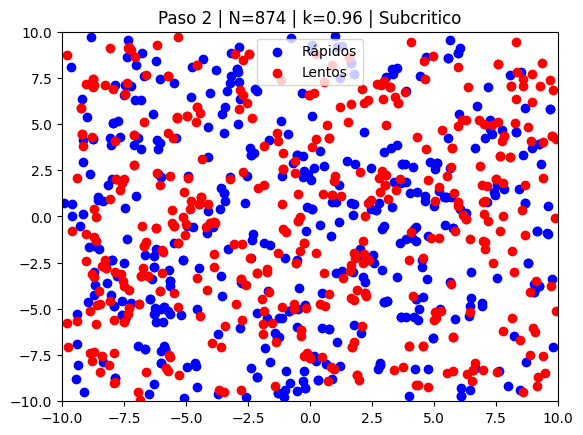

Paso 3: N=873, k=1.00, T=397.8, Estado=Subcritico | Vivos=624, Absorbidos=107, Escapados=10)


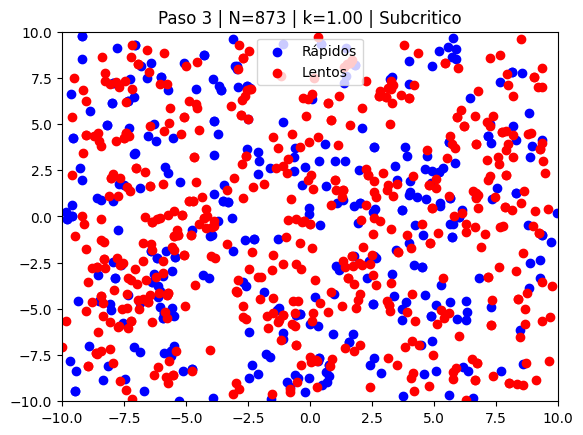

Paso 4: N=883, k=1.01, T=424.4, Estado=Supercritico | Vivos=610, Absorbidos=111, Escapados=9)


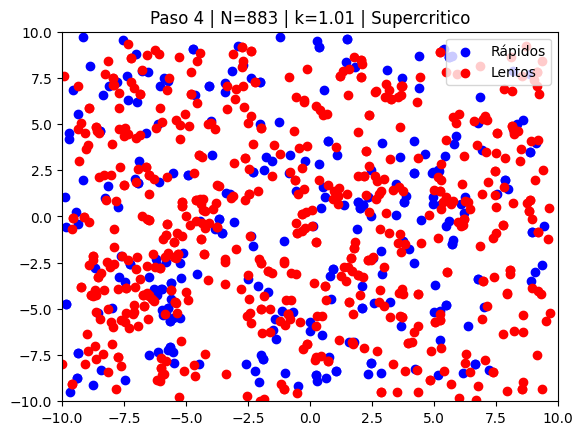

Paso 5: N=895, k=1.01, T=451.8, Estado=Supercritico | Vivos=615, Absorbidos=114, Escapados=7)


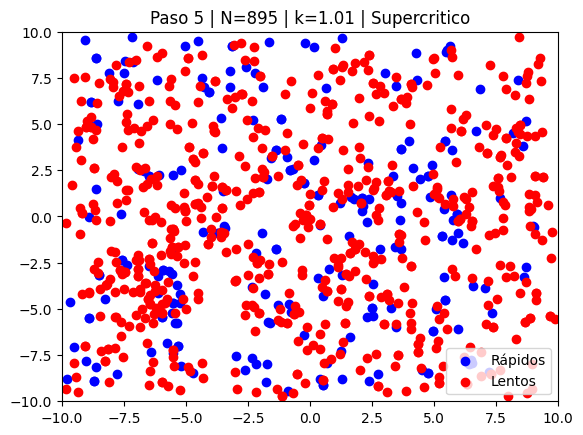

Paso 6: N=945, k=1.06, T=482.2, Estado=Supercritico | Vivos=645, Absorbidos=86, Escapados=2)


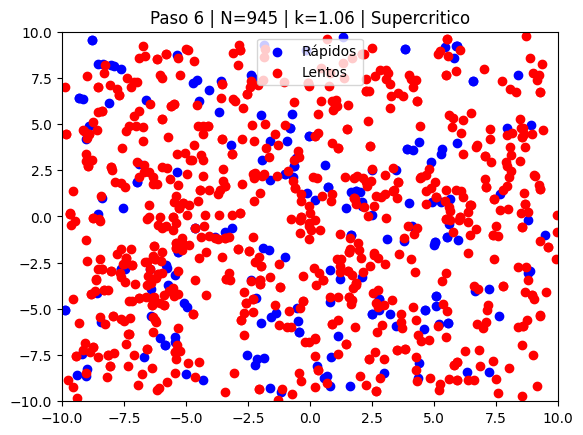

Paso 7: N=972, k=1.03, T=510.0, Estado=Supercritico | Vivos=687, Absorbidos=98, Escapados=11)


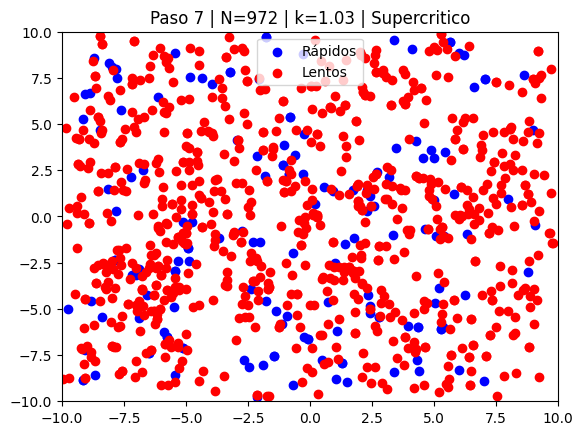

Paso 8: N=1027, k=1.06, T=544.0, Estado=Supercritico | Vivos=681, Absorbidos=104, Escapados=7)


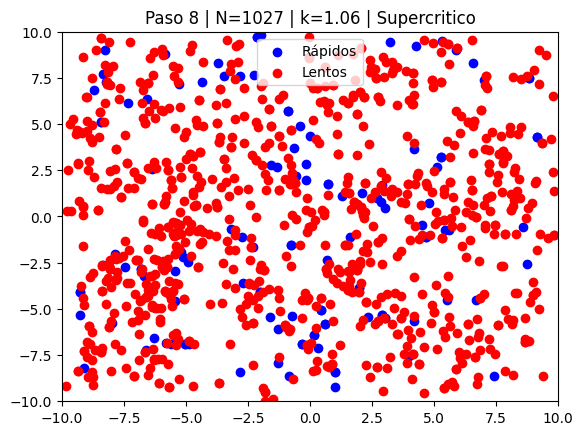

Paso 9: N=1086, k=1.06, T=581.0, Estado=Supercritico | Vivos=713, Absorbidos=112, Escapados=7)


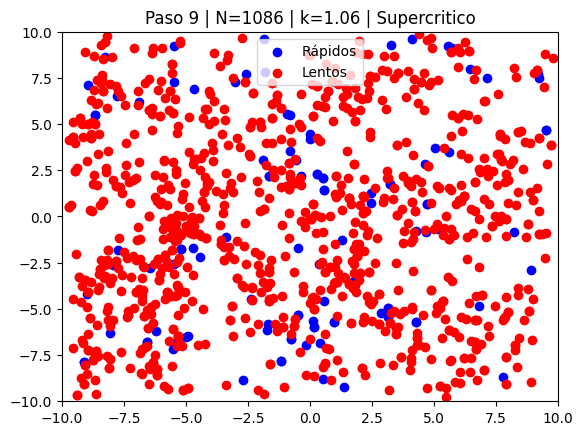

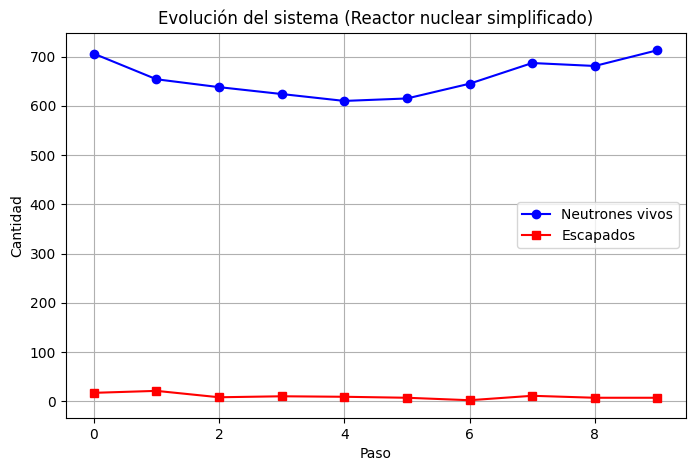

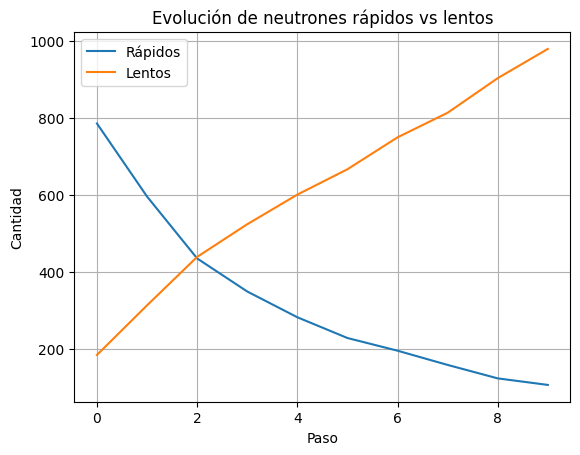

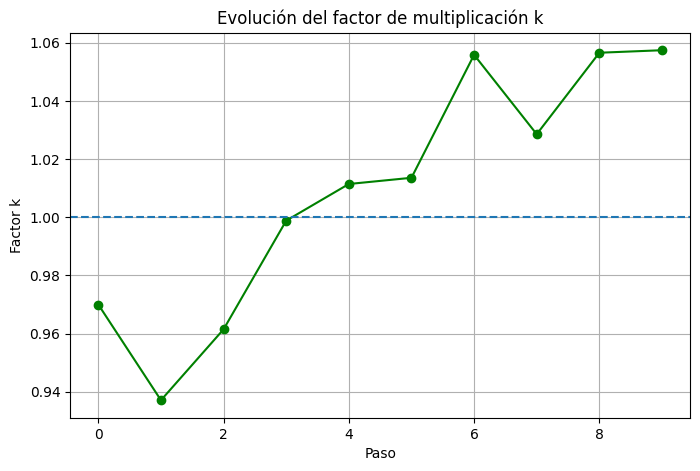

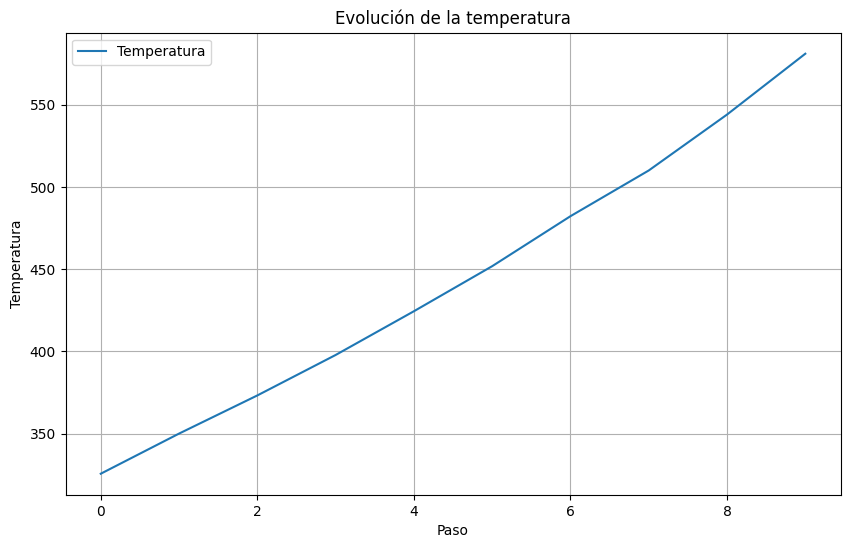

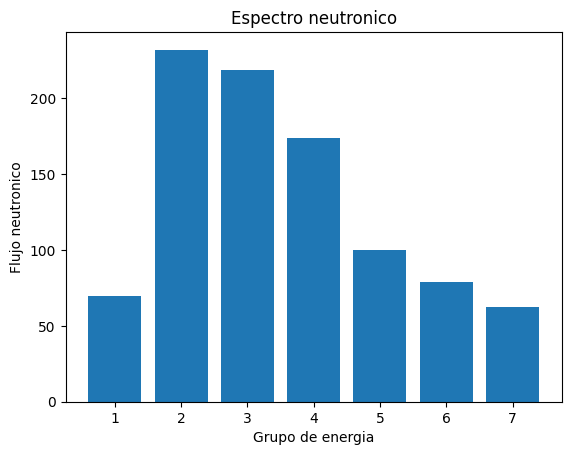

In [ ]:
import random
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# PARÁMETROS
# -----------------------------
num_inicial = 1000
prob_fision = 0.7
prob_muerte = 0.3
neutrones_por_fision = 1.9
agua_litros = 2000
prob_moderacion = min(agua_litros / 10000, 1)
pasos = 10
limite =10
T = 300
T0 = 300
alpha = 0.0005
beta = 0.0008
enfriamiento = 2
energia_por_fision = 0.2
materiales = {
            "H": 0.85,
            "U235": 0.15,

        }
control = 0.6

# -----------------------------
# INICIALIZACIÓN
# -----------------------------
neutrones = []

for _ in range(num_inicial):
    x = random.uniform(-limite, limite)
    y = random.uniform(-limite, limite)
    estado = "rapido"
    grupo = random.randint(1,7)

    neutrones.append([x, y, estado, grupo])

neutrones_anteriores = len(neutrones)

# -----------------------------
# HISTORIALES
# -----------------------------
historial_vivos = []
historial_escapados = []
historial_absorbidos = []
historial_rapidos = []
historial_lentos = []
historial_k = []
historial_T = []
historial_flujo = []

# -----------------------------
# SIMULACIÓN
# -----------------------------
plt.ion()


for paso in range(pasos):
    nuevos = []
    flujo = [0]*7
    for n in neutrones:
        flujo[n[3]-1] += 1
    total_flujo = sum(flujo)
    termicos = flujo[5] + flujo[6]
    total_flujo = sum(flujo)
    if total_flujo > 0:
        fraccion_termica = termicos / total_flujo
    else:
        fraccion_termica = 0

    vivos = 0
    absorbidos = 0
    escapados = 0
    fisiones = 0

    for n in neutrones:
        x, y, estado, grupo = n

        x += random.uniform(-0.5, 0.5)
        y += random.uniform(-0.5, 0.5)


        if abs(x) > limite or abs(y) > limite:
            escapados += 1
            continue

        if estado == "rapido":
            if random.random() < prob_moderacion:
                estado = "lento"
                grupo = min(grupo + 1, 7)


        grupo_idx = grupo - 1

        Sigma_fision = 0
        Sigma_abs = 0
        Sigma_disp = 0

        if total_flujo > 0:
           peso = flujo[grupo_idx] / total_flujo
        else:
           peso = 0
        for mat, densidad in materiales.items():
            sigma_f_material = datos[mat]["fision"][grupo_idx]
            sigma_gamma = datos[mat]["gamma"][grupo_idx]
            sigma_disp_material = datos[mat]["dispersion"][grupo_idx]

            factor_fision = (1 + alpha * (T - T0))
            factor_abs = (1 + beta * (T - T0))

            Sigma_fision += densidad * sigma_f_material * factor_fision * (1 + peso)
            Sigma_abs += densidad * sigma_gamma * factor_abs * (1 + control)
            Sigma_disp += densidad * sigma_disp_material

        Sigma_total = Sigma_fision + Sigma_disp + Sigma_abs

        if Sigma_total == 0:
            continue

        p_fision = Sigma_fision / Sigma_total
        p_abs = Sigma_abs / Sigma_total
        p_disp = Sigma_disp / Sigma_total

        r = random.random()

        if r < p_fision:
            fisiones += 1
            n_nuevos = int(neutrones_por_fision)
            if random.random() < (neutrones_por_fision - n_nuevos):
                n_nuevos += 1
            for _ in range(n_nuevos):
                nuevos.append([x, y, estado, grupo])

        elif r < p_fision + p_abs:
            absorbidos += 1
            continue

        else:
            nuevos.append([x, y, estado, grupo])
            vivos += 1


    T += energia_por_fision * fisiones
    T -= enfriamiento
    T = max(T, 0)
    T = min(T, 2000)

    historial_T.append(T)



    if neutrones_anteriores > 0:
        k = len(nuevos) / neutrones_anteriores
    else:
        k = 0
    if fraccion_termica > 0.4:
      control += 0.03
    elif fraccion_termica < 0.2:
      control -= 0.03
    if k > 1.05:
        control += 0.05
    elif k < 0.95:
      control -= 0.05
    control = max(0, min(control, 1))

    historial_k.append(k)


    if k < 1:
        estado_reactor = "Subcritico"
    elif k == 1:
        estado_reactor = "Critico"
    else:
        estado_reactor = "Supercritico"


    neutrones_anteriores = len(nuevos)
    neutrones = nuevos

    rapidos = sum(1 for n in neutrones if n[2] == "rapido")
    lentos = sum(1 for n in neutrones if n[2] == "lento")

    historial_rapidos.append(rapidos)
    historial_lentos.append(lentos)
    historial_vivos.append(vivos)
    historial_escapados.append(escapados)
    historial_absorbidos.append(absorbidos)
    historial_flujo.append(flujo.copy())


    print(f"Paso {paso}: N={len(neutrones)}, k={k:.2f}, T={T:.1f}, Estado={estado_reactor} | Vivos={vivos}, Absorbidos={absorbidos}, Escapados={escapados})")

    # -----------------------------
    # VISUALIZACIÓN 2D
    # -----------------------------
    plt.clf()

    if neutrones:
        xs_rapidos = [n[0] for n in neutrones if n[2] == "rapido"]
        ys_rapidos = [n[1] for n in neutrones if n[2] == "rapido"]

        xs_lentos = [n[0] for n in neutrones if n[2] == "lento"]
        ys_lentos = [n[1] for n in neutrones if n[2] == "lento"]

        plt.scatter(xs_rapidos, ys_rapidos, color='blue', label="Rápidos")
        plt.scatter(xs_lentos, ys_lentos, color='red', label="Lentos")


    plt.xlim(-limite, limite)
    plt.ylim(-limite, limite)
    plt.title(f"Paso {paso} | N={len(neutrones)} | k={k:.2f} | {estado_reactor}")
    plt.legend()

    plt.pause(0.2)


    if len(neutrones) == 0:
        print("La reacción se extinguió ")
        break

plt.ioff()
plt.show()

# -----------------------------
# GRÁFICA FINAL
# -----------------------------
plt.figure(figsize=(8,5))

plt.plot(historial_vivos, marker='o', color='blue', label="Neutrones vivos")
plt.plot(historial_escapados, marker='s', color='red', label="Escapados")

plt.xlabel("Paso")
plt.ylabel("Cantidad")
plt.title("Evolución del sistema (Reactor nuclear simplificado)")

plt.legend()
plt.grid()

plt.show()
plt.figure()

plt.plot(historial_rapidos, label="Rápidos")
plt.plot(historial_lentos, label="Lentos")

plt.legend()
plt.title("Evolución de neutrones rápidos vs lentos")
plt.xlabel("Paso")
plt.ylabel("Cantidad")

plt.grid()
plt.show()
plt.figure(figsize=(8,5))
plt.plot(historial_k, marker='o', color='green')
plt.axhline(y=1, linestyle='--')

plt.xlabel("Paso")
plt.ylabel("Factor k")
plt.title("Evolución del factor de multiplicación k")

plt.grid()
plt.show()
plt.figure(figsize=(10,6))
plt.plot(historial_T, label="Temperatura")
plt.xlabel("Paso")
plt.ylabel("Temperatura")
plt.title("Evolución de la temperatura")
plt.legend()
plt.grid()
plt.show()
promedio = np.mean(historial_flujo, axis=0)
plt.bar(range(1, 8), promedio)
plt.xlabel("Grupo de energia")
plt.ylabel("Flujo neutronico")
plt.title("Espectro neutronico")
plt.show()